In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Synthetic Data Generation Metrics

In [2]:
colormap = "plasma"

metrics_df = pd.read_excel("CTGAN_Metrics.xlsx")

grouped_metrics = metrics_df.groupby(["dim","batch","epoch"]).agg(
    {
        "mean_ks_numeric":"mean",
        "mean_wasserstein_numeric":"mean",
        "lr_auc":"mean",
        "lr_f1":"mean",
        "rf_auc":"mean",
        "rf_f1":"mean"
    }
).reset_index()

/tmp/ipykernel_963118/487222252.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax[0][0].scatter(
/tmp/ipykernel_963118/487222252.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc2 = ax[0][1].scatter(
/tmp/ipykernel_963118/487222252.py:51: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = ax[1][0].scatter(
/tmp/ipykernel_963118/487222252.py:61: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc4 = ax[1][1].scatter(


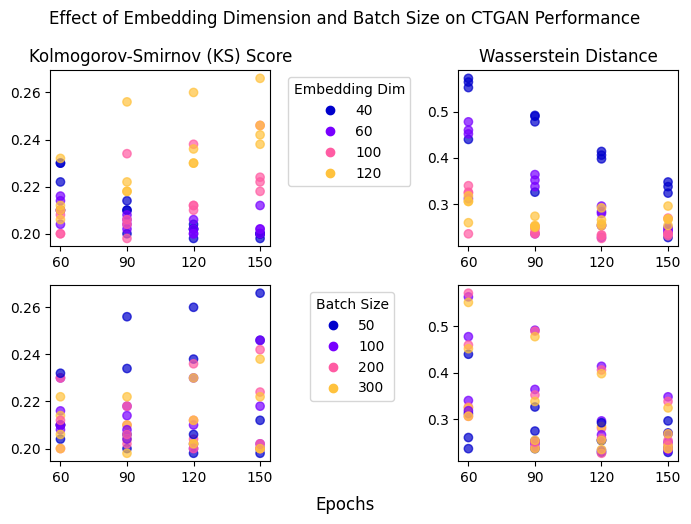

In [3]:
fig, ax = plt.subplots(2,2, figsize=(7,5))

unique_dims = sorted(grouped_metrics["dim"].unique())
dim_colors = {
    d: c for d, c in zip(unique_dims, sns.color_palette("gnuplot2", len(unique_dims)))
}

unique_batches = sorted(grouped_metrics["batch"].unique())
batch_colors = {
    b: c for b, c in zip(unique_batches, sns.color_palette("gnuplot2", len(unique_batches)))
}

dim_handles = [
    plt.Line2D([0], [0], marker='o', color=dim_colors[d], linestyle='', label=f"{d}")
    for d in unique_dims
]
ax[0][0].legend(handles=dim_handles, title="Embedding Dim", bbox_to_anchor=(1.05, 1))

batch_handles = [
    plt.Line2D([0], [0], marker='o', color=batch_colors[b], linestyle='', label=f"{b}")
    for b in unique_batches
]
ax[1][0].legend(handles=batch_handles, title="Batch Size", bbox_to_anchor=(1.15, 1))

## Upper row - Colors based on embedding dimensions

sc1 = ax[0][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_ks_numeric"],
    c=grouped_metrics["dim"].map(dim_colors),
    
    cmap=colormap,
    alpha=0.7
)
ax[0][0].set_title("Kolmogorov-Smirnov (KS) Score")
ax[0][0].set_xticks(grouped_metrics["epoch"].unique())


sc2 = ax[0][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_wasserstein_numeric"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][1].set_title("Wasserstein Distance")
ax[0][1].set_xticks(grouped_metrics["epoch"].unique())

## Lower row - Colors based on batch size

sc3 = ax[1][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_ks_numeric"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][0].set_xticks(grouped_metrics["epoch"].unique())


sc4 = ax[1][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_wasserstein_numeric"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][1].set_xticks(grouped_metrics["epoch"].unique())

fig.text(0.5, -0.01, "Epochs", ha="center", va="center", fontsize=12)
plt.suptitle("Effect of Embedding Dimension and Batch Size on CTGAN Performance")
plt.tight_layout()
plt.savefig("Effect of Embedding Dimension and Batch Size on CTGAN Performance", dpi=300, bbox_inches="tight")

/tmp/ipykernel_963118/2081785265.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax[0][0].scatter(
/tmp/ipykernel_963118/2081785265.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc2 = ax[0][1].scatter(
/tmp/ipykernel_963118/2081785265.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = ax[1][0].scatter(
/tmp/ipykernel_963118/2081785265.py:60: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc4 = ax[1][1].scatter(


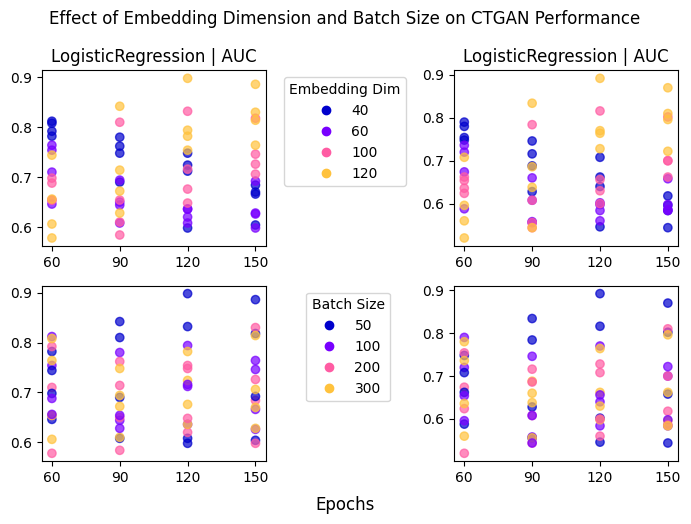

In [4]:
fig, ax = plt.subplots(2,2, figsize=(7,5))

unique_dims = sorted(grouped_metrics["dim"].unique())
dim_colors = {
    d: c for d, c in zip(unique_dims, sns.color_palette("gnuplot2", len(unique_dims)))
}

unique_batches = sorted(grouped_metrics["batch"].unique())
batch_colors = {
    b: c for b, c in zip(unique_batches, sns.color_palette("gnuplot2", len(unique_batches)))
}

dim_handles = [
    plt.Line2D([0], [0], marker='o', color=dim_colors[d], linestyle='', label=f"{d}")
    for d in unique_dims
]
ax[0][0].legend(handles=dim_handles, title="Embedding Dim", bbox_to_anchor=(1.05, 1))

batch_handles = [
    plt.Line2D([0], [0], marker='o', color=batch_colors[b], linestyle='', label=f"{b}")
    for b in unique_batches
]
ax[1][0].legend(handles=batch_handles, title="Batch Size", bbox_to_anchor=(1.15, 1))

## Upper row - Colors based on embedding dimensions

sc1 = ax[0][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_auc"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][0].set_title("LogisticRegression | AUC")
ax[0][0].set_xticks(grouped_metrics["epoch"].unique())


sc2 = ax[0][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_f1"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][1].set_title("LogisticRegression | AUC")
ax[0][1].set_xticks(grouped_metrics["epoch"].unique())

## Lower row - Colors based on batch size

sc3 = ax[1][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_auc"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][0].set_xticks(grouped_metrics["epoch"].unique())


sc4 = ax[1][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_f1"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][1].set_xticks(grouped_metrics["epoch"].unique())

fig.text(0.5, -0.01, "Epochs", ha="center", va="center", fontsize=12)
plt.suptitle("Effect of Embedding Dimension and Batch Size on CTGAN Performance")
plt.tight_layout()
plt.savefig("Effect of Embedding Dimension and Batch Size on CTGAN Performance", dpi=300, bbox_inches="tight")

/tmp/ipykernel_963118/3091097219.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax[0][0].scatter(
/tmp/ipykernel_963118/3091097219.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc2 = ax[0][1].scatter(
/tmp/ipykernel_963118/3091097219.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = ax[1][0].scatter(
/tmp/ipykernel_963118/3091097219.py:60: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc4 = ax[1][1].scatter(


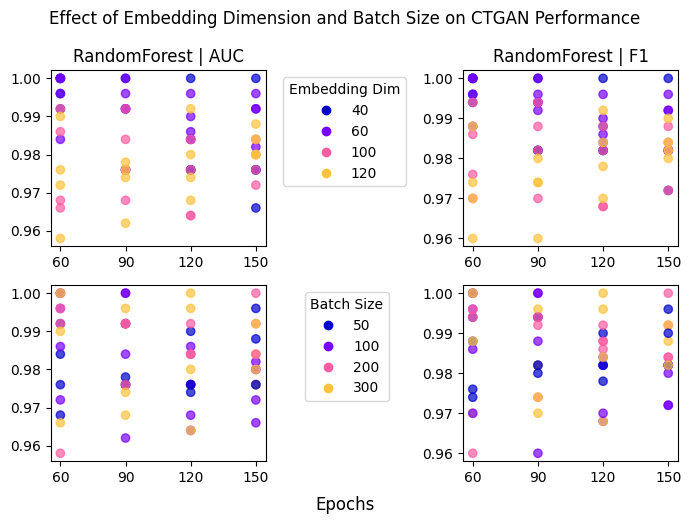

In [7]:
fig, ax = plt.subplots(2,2, figsize=(7,5))

unique_dims = sorted(grouped_metrics["dim"].unique())
dim_colors = {
    d: c for d, c in zip(unique_dims, sns.color_palette("gnuplot2", len(unique_dims)))
}

unique_batches = sorted(grouped_metrics["batch"].unique())
batch_colors = {
    b: c for b, c in zip(unique_batches, sns.color_palette("gnuplot2", len(unique_batches)))
}

dim_handles = [
    plt.Line2D([0], [0], marker='o', color=dim_colors[d], linestyle='', label=f"{d}")
    for d in unique_dims
]
ax[0][0].legend(handles=dim_handles, title="Embedding Dim", bbox_to_anchor=(1.05, 1))

batch_handles = [
    plt.Line2D([0], [0], marker='o', color=batch_colors[b], linestyle='', label=f"{b}")
    for b in unique_batches
]
ax[1][0].legend(handles=batch_handles, title="Batch Size", bbox_to_anchor=(1.15, 1))

## Upper row - Colors based on embedding dimensions

sc1 = ax[0][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_auc"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][0].set_title("RandomForest | AUC")
ax[0][0].set_xticks(grouped_metrics["epoch"].unique())


sc2 = ax[0][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_f1"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][1].set_title("RandomForest | F1")
ax[0][1].set_xticks(grouped_metrics["epoch"].unique())

## Lower row - Colors based on batch size

sc3 = ax[1][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_auc"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][0].set_xticks(grouped_metrics["epoch"].unique())


sc4 = ax[1][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_f1"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][1].set_xticks(grouped_metrics["epoch"].unique())

fig.text(0.5, -0.01, "Epochs", ha="center", va="center", fontsize=12)
plt.suptitle("Effect of Embedding Dimension and Batch Size on CTGAN Performance")
plt.tight_layout()
plt.savefig("Effect of Embedding Dimension and Batch Size on CTGAN Performance", dpi=300, bbox_inches="tight")

In [8]:
metrics_df = pd.read_excel("CTAB_GAN_Metrics.xlsx")

grouped_metrics = metrics_df.groupby(["dim","batch","epoch"]).agg(
    {
        "mean_ks_numeric":"mean",
        "mean_wasserstein_numeric":"mean",
        "lr_auc":"mean",
        "lr_f1":"mean",
        "rf_auc":"mean",
        "rf_f1":"mean"
    }
).reset_index()

/tmp/ipykernel_963118/3792259246.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax[0][0].scatter(
/tmp/ipykernel_963118/3792259246.py:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc2 = ax[0][1].scatter(
/tmp/ipykernel_963118/3792259246.py:49: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = ax[1][0].scatter(
/tmp/ipykernel_963118/3792259246.py:58: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc4 = ax[1][1].scatter(


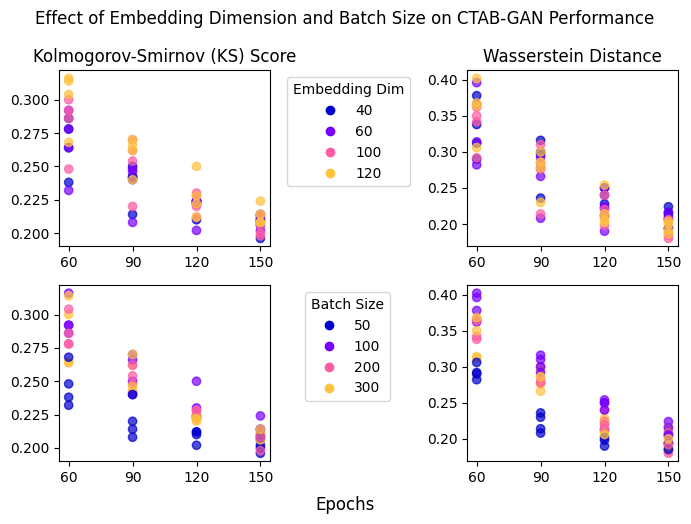

In [9]:
fig, ax = plt.subplots(2,2, figsize=(7,5))

unique_dims = sorted(grouped_metrics["dim"].unique())
dim_colors = {
    d: c for d, c in zip(unique_dims, sns.color_palette("gnuplot2", len(unique_dims)))
}

unique_batches = sorted(grouped_metrics["batch"].unique())
batch_colors = {
    b: c for b, c in zip(unique_batches, sns.color_palette("gnuplot2", len(unique_batches)))
}

dim_handles = [
    plt.Line2D([0], [0], marker='o', color=dim_colors[d], linestyle='', label=f"{d}")
    for d in unique_dims
]
ax[0][0].legend(handles=dim_handles, title="Embedding Dim", bbox_to_anchor=(1.05, 1))

batch_handles = [
    plt.Line2D([0], [0], marker='o', color=batch_colors[b], linestyle='', label=f"{b}")
    for b in unique_batches
]
ax[1][0].legend(handles=batch_handles, title="Batch Size", bbox_to_anchor=(1.60, 1))

## Upper row - Colors based on embedding dimensions

sc1 = ax[0][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_ks_numeric"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][0].set_title("Kolmogorov-Smirnov (KS) Score")
ax[0][0].set_xticks(grouped_metrics["epoch"].unique())

sc2 = ax[0][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_wasserstein_numeric"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][1].set_title("Wasserstein Distance")
ax[0][1].set_xticks(grouped_metrics["epoch"].unique())

## Lower row - Colors based on batch size

sc3 = ax[1][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_ks_numeric"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][0].set_xticks(grouped_metrics["epoch"].unique())

sc4 = ax[1][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_wasserstein_numeric"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][1].set_xticks(grouped_metrics["epoch"].unique())

fig.text(0.5, -0.01, "Epochs", ha="center", va="center", fontsize=12)
plt.suptitle("Effect of Embedding Dimension and Batch Size on CTAB-GAN Performance")
plt.tight_layout()
plt.savefig("Effect of Embedding Dimension and Batch Size on CTAB-GAN Performance", dpi=300, bbox_inches="tight")

/tmp/ipykernel_963118/1642664296.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax[0][0].scatter(
/tmp/ipykernel_963118/1642664296.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc2 = ax[0][1].scatter(
/tmp/ipykernel_963118/1642664296.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = ax[1][0].scatter(
/tmp/ipykernel_963118/1642664296.py:60: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc4 = ax[1][1].scatter(


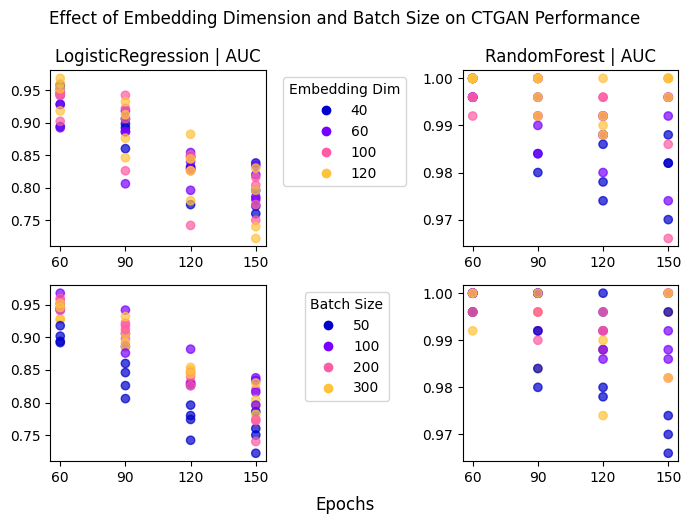

In [10]:
fig, ax = plt.subplots(2,2, figsize=(7,5))

unique_dims = sorted(grouped_metrics["dim"].unique())
dim_colors = {
    d: c for d, c in zip(unique_dims, sns.color_palette("gnuplot2", len(unique_dims)))
}

unique_batches = sorted(grouped_metrics["batch"].unique())
batch_colors = {
    b: c for b, c in zip(unique_batches, sns.color_palette("gnuplot2", len(unique_batches)))
}

dim_handles = [
    plt.Line2D([0], [0], marker='o', color=dim_colors[d], linestyle='', label=f"{d}")
    for d in unique_dims
]
ax[0][0].legend(handles=dim_handles, title="Embedding Dim", bbox_to_anchor=(1.05, 1))

batch_handles = [
    plt.Line2D([0], [0], marker='o', color=batch_colors[b], linestyle='', label=f"{b}")
    for b in unique_batches
]
ax[1][0].legend(handles=batch_handles, title="Batch Size", bbox_to_anchor=(1.15, 1))

## Upper row - Colors based on embedding dimensions

sc1 = ax[0][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_auc"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][0].set_title("LogisticRegression | AUC")
ax[0][0].set_xticks(grouped_metrics["epoch"].unique())


sc2 = ax[0][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_auc"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][1].set_title("RandomForest | AUC")
ax[0][1].set_xticks(grouped_metrics["epoch"].unique())

## Lower row - Colors based on batch size

sc3 = ax[1][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_auc"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][0].set_xticks(grouped_metrics["epoch"].unique())


sc4 = ax[1][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_auc"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][1].set_xticks(grouped_metrics["epoch"].unique())

fig.text(0.5, -0.01, "Epochs", ha="center", va="center", fontsize=12)
plt.suptitle("Effect of Embedding Dimension and Batch Size on CTGAN Performance")
plt.tight_layout()
plt.savefig("Effect of Embedding Dimension and Batch Size on CTGAN Performance", dpi=300, bbox_inches="tight")

/tmp/ipykernel_963118/3225175458.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax[0][0].scatter(
/tmp/ipykernel_963118/3225175458.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc2 = ax[0][1].scatter(
/tmp/ipykernel_963118/3225175458.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = ax[1][0].scatter(
/tmp/ipykernel_963118/3225175458.py:60: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc4 = ax[1][1].scatter(


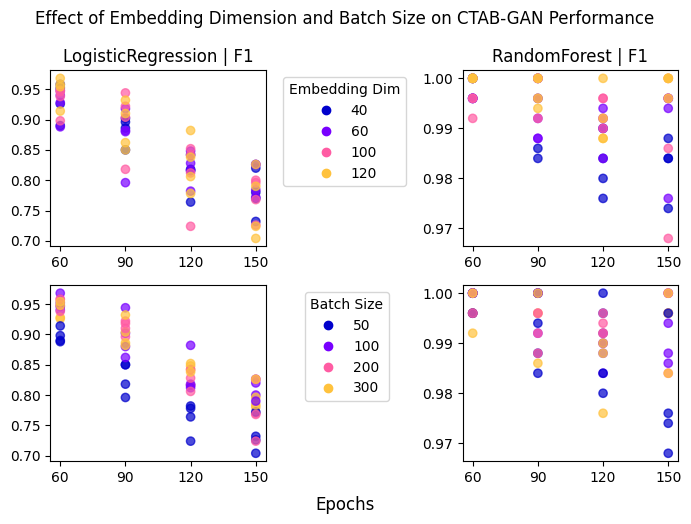

In [11]:
fig, ax = plt.subplots(2,2, figsize=(7,5))

unique_dims = sorted(grouped_metrics["dim"].unique())
dim_colors = {
    d: c for d, c in zip(unique_dims, sns.color_palette("gnuplot2", len(unique_dims)))
}

unique_batches = sorted(grouped_metrics["batch"].unique())
batch_colors = {
    b: c for b, c in zip(unique_batches, sns.color_palette("gnuplot2", len(unique_batches)))
}

dim_handles = [
    plt.Line2D([0], [0], marker='o', color=dim_colors[d], linestyle='', label=f"{d}")
    for d in unique_dims
]
ax[0][0].legend(handles=dim_handles, title="Embedding Dim", bbox_to_anchor=(1.05, 1))

batch_handles = [
    plt.Line2D([0], [0], marker='o', color=batch_colors[b], linestyle='', label=f"{b}")
    for b in unique_batches
]
ax[1][0].legend(handles=batch_handles, title="Batch Size", bbox_to_anchor=(1.15, 1))

## Upper row - Colors based on embedding dimensions

sc1 = ax[0][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_f1"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][0].set_title("LogisticRegression | F1")
ax[0][0].set_xticks(grouped_metrics["epoch"].unique())


sc2 = ax[0][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_f1"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][1].set_title("RandomForest | F1")
ax[0][1].set_xticks(grouped_metrics["epoch"].unique())

## Lower row - Colors based on batch size

sc3 = ax[1][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_f1"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][0].set_xticks(grouped_metrics["epoch"].unique())


sc4 = ax[1][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_f1"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][1].set_xticks(grouped_metrics["epoch"].unique())

fig.text(0.5, -0.01, "Epochs", ha="center", va="center", fontsize=12)
plt.suptitle("Effect of Embedding Dimension and Batch Size on CTAB-GAN Performance")
plt.tight_layout()
plt.savefig("Effect of Embedding Dimension and Batch Size on CTAB-GAN Performance", dpi=300, bbox_inches="tight")

In [12]:
metrics_df = pd.read_excel("FCT_GAN_Metrics.xlsx")

grouped_metrics = metrics_df.groupby(["dim","batch","epoch"]).agg(
    {
        "mean_ks_numeric":"mean",
        "mean_wasserstein_numeric":"mean",
        "lr_auc":"mean",
        "lr_f1":"mean",
        "rf_auc":"mean",
        "rf_f1":"mean",
    }
).reset_index()

/tmp/ipykernel_963118/1742999506.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax[0][0].scatter(
/tmp/ipykernel_963118/1742999506.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc2 = ax[0][1].scatter(
/tmp/ipykernel_963118/1742999506.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = ax[1][0].scatter(
/tmp/ipykernel_963118/1742999506.py:60: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc4 = ax[1][1].scatter(


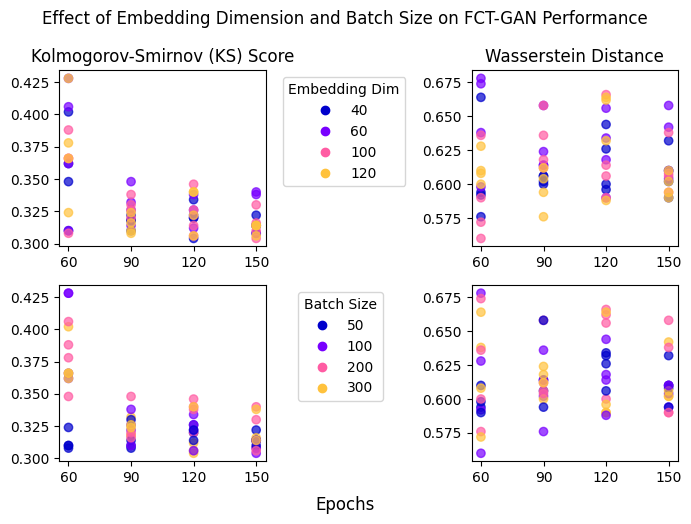

In [13]:
fig, ax = plt.subplots(2,2, figsize=(7,5))

unique_dims = sorted(grouped_metrics["dim"].unique())
dim_colors = {
    d: c for d, c in zip(unique_dims, sns.color_palette("gnuplot2", len(unique_dims)))
}

unique_batches = sorted(grouped_metrics["batch"].unique())
batch_colors = {
    b: c for b, c in zip(unique_batches, sns.color_palette("gnuplot2", len(unique_batches)))
}

dim_handles = [
    plt.Line2D([0], [0], marker='o', color=dim_colors[d], linestyle='', label=f"{d}")
    for d in unique_dims
]
ax[0][0].legend(handles=dim_handles, title="Embedding Dim", bbox_to_anchor=(1.05, 1))

batch_handles = [
    plt.Line2D([0], [0], marker='o', color=batch_colors[b], linestyle='', label=f"{b}")
    for b in unique_batches
]
ax[1][0].legend(handles=batch_handles, title="Batch Size", bbox_to_anchor=(1.60, 1))

## Upper row - Colors based on embedding dimensions

sc1 = ax[0][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_ks_numeric"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][0].set_title("Kolmogorov-Smirnov (KS) Score")
ax[0][0].set_xticks(grouped_metrics["epoch"].unique())


sc2 = ax[0][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_wasserstein_numeric"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][1].set_title("Wasserstein Distance")
ax[0][1].set_xticks(grouped_metrics["epoch"].unique())

## Lower row - Colors based on batch size

sc3 = ax[1][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_ks_numeric"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][0].set_xticks(grouped_metrics["epoch"].unique())


sc4 = ax[1][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["mean_wasserstein_numeric"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][1].set_xticks(grouped_metrics["epoch"].unique())

fig.text(0.5, -0.01, "Epochs", ha="center", va="center", fontsize=12)
plt.suptitle("Effect of Embedding Dimension and Batch Size on FCT-GAN Performance")
plt.tight_layout()
plt.savefig("Effect of Embedding Dimension and Batch Size on FCT-GAN Performance", dpi=300, bbox_inches="tight")

/tmp/ipykernel_963118/113369146.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax[0][0].scatter(
/tmp/ipykernel_963118/113369146.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc2 = ax[0][1].scatter(
/tmp/ipykernel_963118/113369146.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = ax[1][0].scatter(
/tmp/ipykernel_963118/113369146.py:60: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc4 = ax[1][1].scatter(


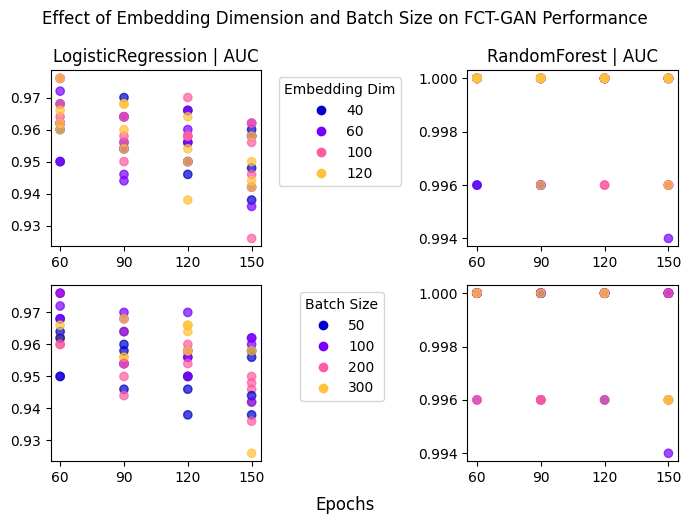

In [14]:
fig, ax = plt.subplots(2,2, figsize=(7,5))

unique_dims = sorted(grouped_metrics["dim"].unique())
dim_colors = {
    d: c for d, c in zip(unique_dims, sns.color_palette("gnuplot2", len(unique_dims)))
}

unique_batches = sorted(grouped_metrics["batch"].unique())
batch_colors = {
    b: c for b, c in zip(unique_batches, sns.color_palette("gnuplot2", len(unique_batches)))
}

dim_handles = [
    plt.Line2D([0], [0], marker='o', color=dim_colors[d], linestyle='', label=f"{d}")
    for d in unique_dims
]
ax[0][0].legend(handles=dim_handles, title="Embedding Dim", bbox_to_anchor=(1.05, 1))

batch_handles = [
    plt.Line2D([0], [0], marker='o', color=batch_colors[b], linestyle='', label=f"{b}")
    for b in unique_batches
]
ax[1][0].legend(handles=batch_handles, title="Batch Size", bbox_to_anchor=(1.15, 1))

## Upper row - Colors based on embedding dimensions

sc1 = ax[0][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_auc"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][0].set_title("LogisticRegression | AUC")
ax[0][0].set_xticks(grouped_metrics["epoch"].unique())


sc2 = ax[0][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_auc"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][1].set_title("RandomForest | AUC")
ax[0][1].set_xticks(grouped_metrics["epoch"].unique())

## Lower row - Colors based on batch size

sc3 = ax[1][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_auc"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][0].set_xticks(grouped_metrics["epoch"].unique())


sc4 = ax[1][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_auc"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][1].set_xticks(grouped_metrics["epoch"].unique())

fig.text(0.5, -0.01, "Epochs", ha="center", va="center", fontsize=12)
plt.suptitle("Effect of Embedding Dimension and Batch Size on FCT-GAN Performance")
plt.tight_layout()
plt.savefig("Effect of Embedding Dimension and Batch Size on FCT-GAN Performance", dpi=300, bbox_inches="tight")

/tmp/ipykernel_963118/3863841559.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax[0][0].scatter(
/tmp/ipykernel_963118/3863841559.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc2 = ax[0][1].scatter(
/tmp/ipykernel_963118/3863841559.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc3 = ax[1][0].scatter(
/tmp/ipykernel_963118/3863841559.py:60: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc4 = ax[1][1].scatter(


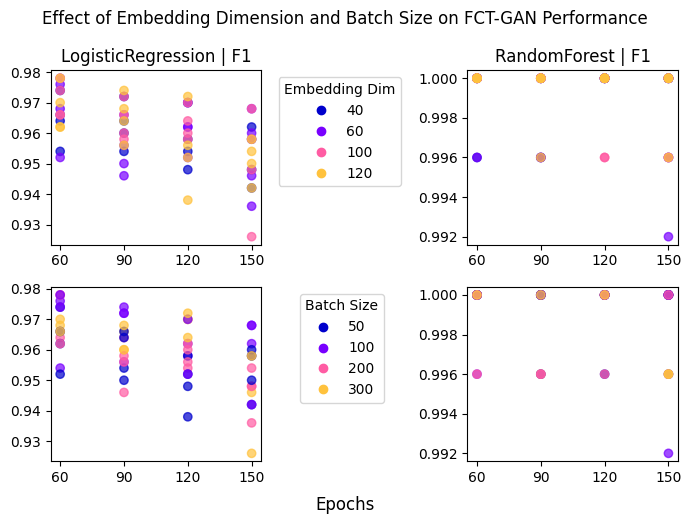

In [15]:
fig, ax = plt.subplots(2,2, figsize=(7,5))

unique_dims = sorted(grouped_metrics["dim"].unique())
dim_colors = {
    d: c for d, c in zip(unique_dims, sns.color_palette("gnuplot2", len(unique_dims)))
}

unique_batches = sorted(grouped_metrics["batch"].unique())
batch_colors = {
    b: c for b, c in zip(unique_batches, sns.color_palette("gnuplot2", len(unique_batches)))
}

dim_handles = [
    plt.Line2D([0], [0], marker='o', color=dim_colors[d], linestyle='', label=f"{d}")
    for d in unique_dims
]
ax[0][0].legend(handles=dim_handles, title="Embedding Dim", bbox_to_anchor=(1.05, 1))

batch_handles = [
    plt.Line2D([0], [0], marker='o', color=batch_colors[b], linestyle='', label=f"{b}")
    for b in unique_batches
]
ax[1][0].legend(handles=batch_handles, title="Batch Size", bbox_to_anchor=(1.15, 1))

## Upper row - Colors based on embedding dimensions

sc1 = ax[0][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_f1"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][0].set_title("LogisticRegression | F1")
ax[0][0].set_xticks(grouped_metrics["epoch"].unique())


sc2 = ax[0][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_f1"],
    c=grouped_metrics["dim"].map(dim_colors),
    cmap=colormap,
    alpha=0.7
)
ax[0][1].set_title("RandomForest | F1")
ax[0][1].set_xticks(grouped_metrics["epoch"].unique())

## Lower row - Colors based on batch size

sc3 = ax[1][0].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["lr_f1"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][0].set_xticks(grouped_metrics["epoch"].unique())


sc4 = ax[1][1].scatter(
    grouped_metrics["epoch"],
    grouped_metrics["rf_f1"],
    c=grouped_metrics["batch"].map(batch_colors),
    cmap=colormap,
    alpha=0.7
)
ax[1][1].set_xticks(grouped_metrics["epoch"].unique())

fig.text(0.5, -0.01, "Epochs", ha="center", va="center", fontsize=12)
plt.suptitle("Effect of Embedding Dimension and Batch Size on FCT-GAN Performance")
plt.tight_layout()
plt.savefig("Effect of Embedding Dimension and Batch Size on FCT-GAN Performance", dpi=300, bbox_inches="tight")

In [16]:
base = pd.read_csv("synth_base_data.csv")
ctgan_df = pd.read_excel("CTGAN_Metrics.xlsx")
ctab_df = pd.read_excel("CTAB_GAN_Metrics.xlsx")
fct_df = pd.read_excel("FCT_GAN_Metrics.xlsx")


ctgan_df["type"] = "CTGAN"
ctab_df["type"] = "CTAB-GAN"
fct_df["type"] = "FCT-GAN"

complete_df = pd.concat([ctgan_df,ctab_df,fct_df])

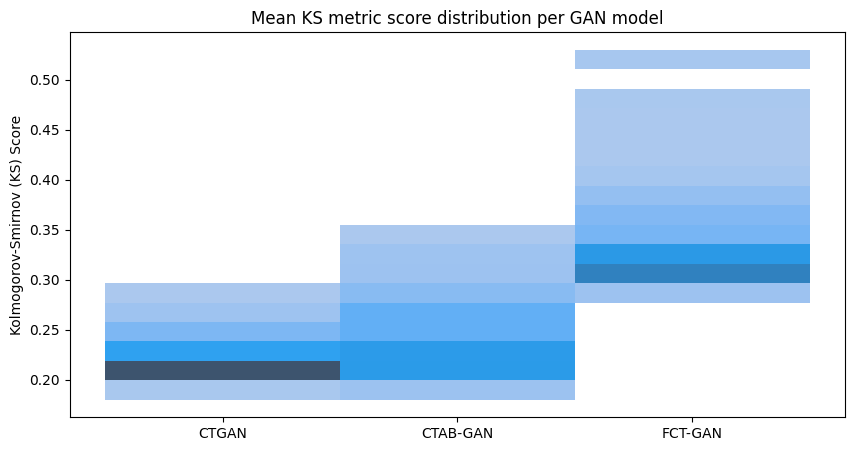

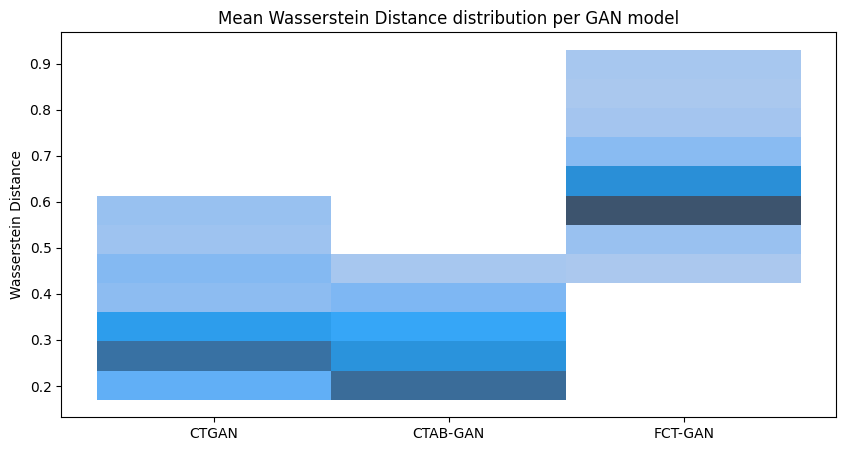

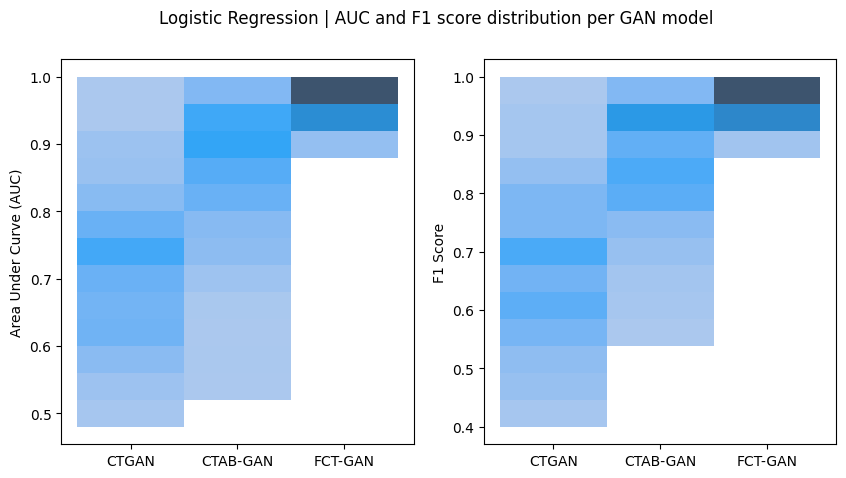

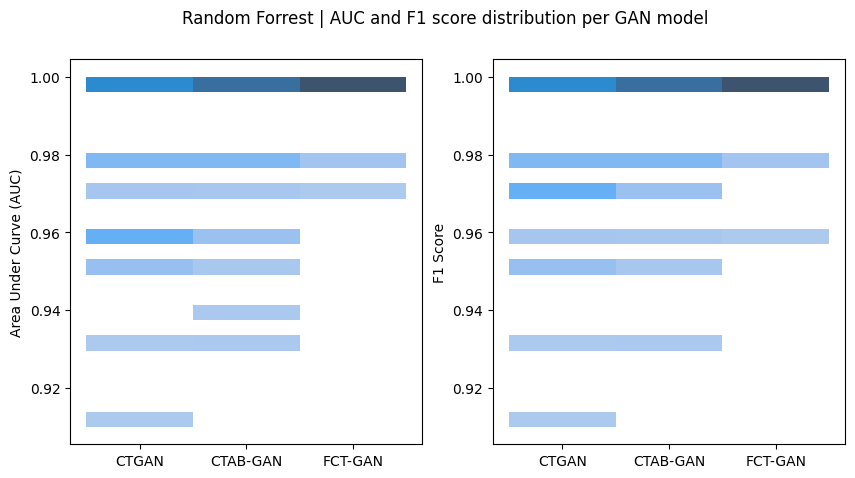

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10,5))

sns.histplot(
    data=complete_df,
    x="type",
    y="mean_ks_numeric",
    ax=ax
)
ax.set_title("Mean KS metric score distribution per GAN model")
ax.set_xlabel(None)
ax.set_ylabel("Kolmogorov-Smirnov (KS) Score")
plt.savefig("KS_score_per_gan_model.png", dpi=300)

fig, ax = plt.subplots(1, 1, figsize=(10,5))

sns.histplot(
    data=complete_df,
    x="type",
    y="mean_wasserstein_numeric",
    ax=ax
)
ax.set_title("Mean Wasserstein Distance distribution per GAN model")
ax.set_xlabel(None)
ax.set_ylabel("Wasserstein Distance")
plt.savefig("WD_score_per_gan_model.png", dpi=300)

fig, ax = plt.subplots(1, 2, figsize=(10,5))

sns.histplot(
    data=complete_df,
    x="type",
    y="lr_auc",
    ax=ax[0]
)

sns.histplot(
    data=complete_df,
    x="type",
    y="lr_f1",
    ax=ax[1]
)

plt.suptitle("Logistic Regression | AUC and F1 score distribution per GAN model")
ax[0].set_xlabel(None)
ax[0].set_ylabel("Area Under Curve (AUC)")
ax[1].set_xlabel(None)
ax[1].set_ylabel("F1 Score")
plt.savefig("lr_auc_f1_per_gan_model.png", dpi=300)


fig, ax = plt.subplots(1, 2, figsize=(10,5))

sns.histplot(
    data=complete_df,
    x="type",
    y="rf_auc",
    ax=ax[0]
)

sns.histplot(
    data=complete_df,
    x="type",
    y="rf_f1",
    ax=ax[1]
)

plt.suptitle("Random Forrest | AUC and F1 score distribution per GAN model")
ax[0].set_xlabel(None)
ax[0].set_ylabel("Area Under Curve (AUC)")
ax[1].set_xlabel(None)
ax[1].set_ylabel("F1 Score")
plt.savefig("rf_auc_f1_per_gan_model.png", dpi=300)

In [18]:
synth_base = pd.read_csv("synth_base_data.csv")
synth_ctgan = pd.read_csv("synthetic_ctgan_data.csv")
synth_ctab = pd.read_csv("synthetic_ctab_data.csv")
synth_fct = pd.read_csv("synthetic_fct_data.csv")

print(len(synth_base), len(synth_ctab), len(synth_ctgan), len(synth_fct))

162 162 162 162


In [19]:
target_ratios = ["accrual","roa","roe","de_ratio","rect_act","rect_turn"]

def build_long_df(real, synthetic, label):
    df_real = real[target_ratios].assign(Source="Real", GAN=label)
    df_syn  = synthetic[target_ratios].assign(Source="Synthetic", GAN=label)
    return pd.concat([df_real, df_syn], axis=0)

df_ctgan = build_long_df(synth_base, synth_ctgan, "CTGAN")
df_ctab  = build_long_df(synth_base, synth_ctab, "CTAB-GAN")
df_fct   = build_long_df(synth_base, synth_fct, "FCT-GAN")

kde_df = pd.concat([df_ctgan, df_ctab, df_fct], axis=0)

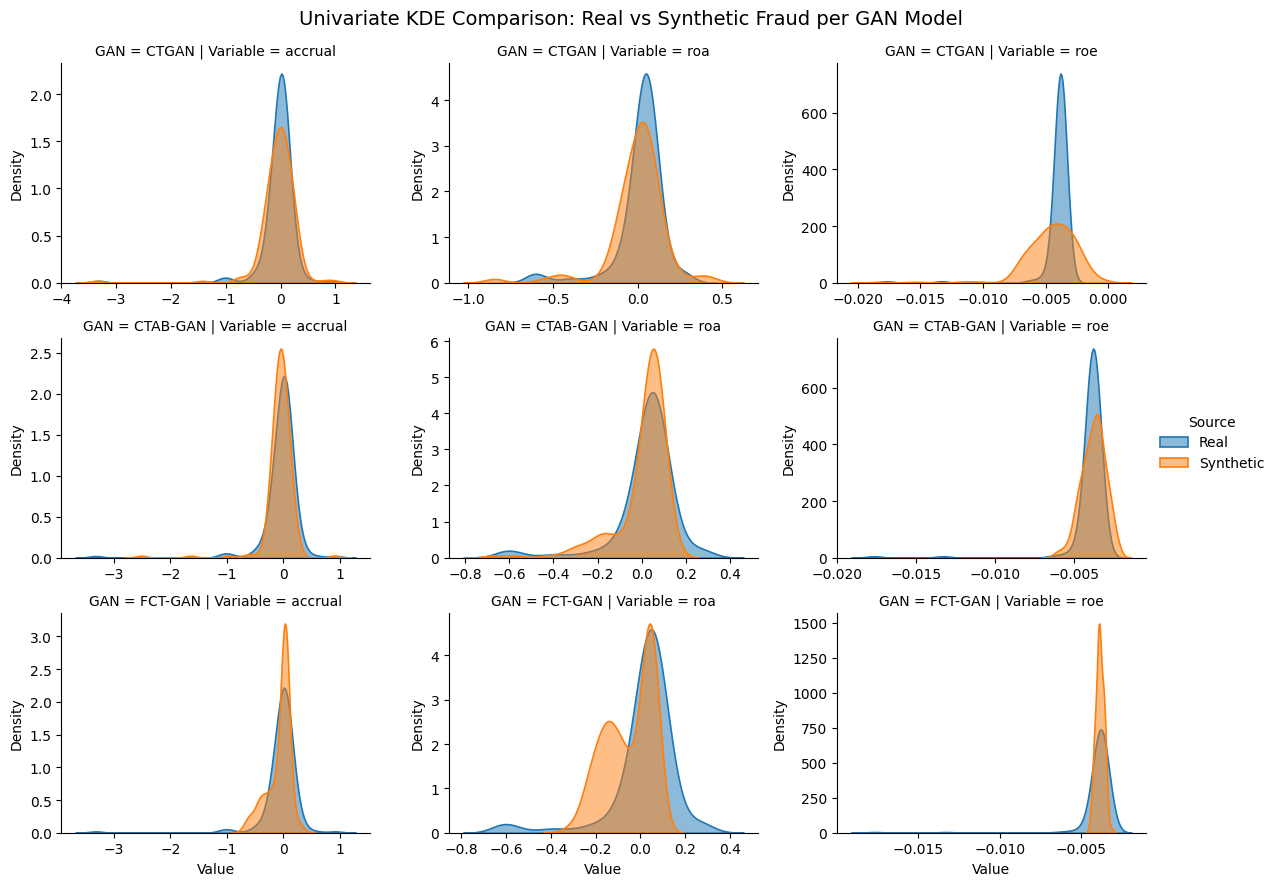

In [22]:
source = kde_df[["accrual","roa","roe","Source","GAN"]]

g = sns.FacetGrid(
    source.melt(id_vars=["Source", "GAN"], var_name="Variable", value_name="Value"),
    row="GAN",
    col="Variable",
    hue="Source",
    sharex=False,
    sharey=False,
    height=3,
    aspect=1.3
)

g.map(sns.kdeplot, "Value", fill=True, alpha=0.5, linewidth=1.2)
g.add_legend()

plt.subplots_adjust(top=0.92)
g.fig.suptitle("Univariate KDE Comparison: Real vs Synthetic Fraud per GAN Model", fontsize=14)

plt.savefig("kde_comparison_gan.png", dpi=300)
plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
train_df = pd.read_excel("Classification_model_performance_per_fold_training.xlsx", sheet_name="Sheet1")
test_df  = pd.read_excel("Classification_model_performance_per_fold.xlsx")

train_df = train_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

test_df = test_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

# for model in set(train_df["model_name"].unique()):
#     for version in set(train_df["data_version"].unique()):

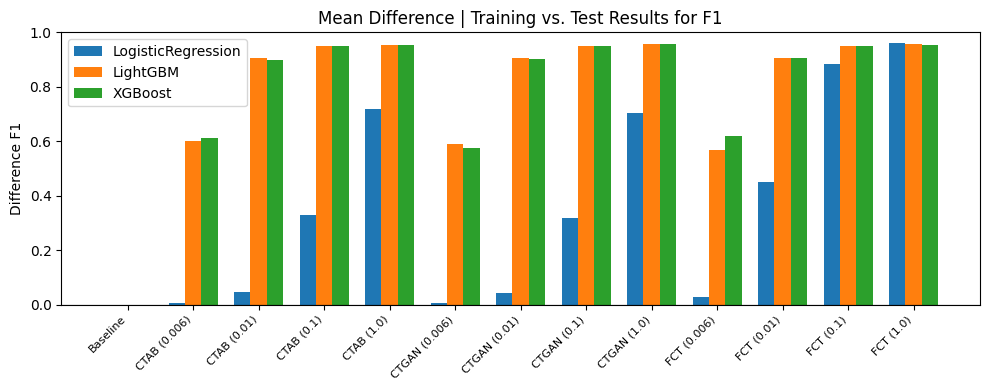

In [24]:
# Load data
train_df = pd.read_excel("Classification_model_performance_per_fold_training.xlsx", sheet_name="Sheet1")
test_df  = pd.read_excel("Classification_model_performance_per_fold.xlsx")

train_df = train_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

test_df = test_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

# Make sure column names are consistent
train_df = train_df.rename(columns={
    "f1": "train_f1",
    "prec": "train_prec",
    "rec": "train_rec",
    "auc": "train_auc",
    "pr_auc": "train_pr_auc"
})

test_df = test_df.rename(columns={
    "f1": "test_f1",
    "prec": "test_prec",
    "rec": "test_rec",
    "auc": "test_auc",
    "pr_auc": "test_pr_auc"
})


# Aggregate per model + data_version (mean over folds)
train_agg = (
    train_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["train_f1"]]
    .mean()
)
test_agg = (
    test_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["test_f1"]]
    .mean()
)

# Merge train + test
df = pd.merge(train_agg, test_agg, on=["model_name", "data_version"], how="inner")

# --- 2. Prepare ordering and compute gap ---
# Nice ordering of GAN versions on x-axis
order = [
    "baseline",
    "ctab", "ctab_0.01", "ctab_0.1", "ctab_1.0",
    "ctgan", "ctgan_0.01", "ctgan_0.1", "ctgan_1.0",
    "fct", "fct_0.01", "fct_0.1", "fct_1.0"
]

df["data_version"] = pd.Categorical(df["data_version"], categories=order, ordered=True)
df = df.sort_values(["data_version", "model_name"])

# Generalization gap = train - test
df["gap_f1"] = df["train_f1"] - df["test_f1"]

# --- 3. Single grouped bar plot: F1 gap by data_version and model ---
models = ["LogisticRegression", "LightGBM", "XGBoost"]
colors = {
    "LogisticRegression": "tab:blue",
    "LightGBM": "tab:orange",
    "XGBoost": "tab:green",
}

x_labels = [v for v in order if v in df["data_version"].unique()]
x = np.arange(len(x_labels))
width = 0.25

plt.figure(figsize=(10, 4))

for i, model in enumerate(models):
    df_m = df[df["model_name"] == model]
    # align with x_labels order
    df_m = df_m.set_index("data_version").reindex(x_labels)
    gaps = df_m["gap_f1"].values

    plt.bar(
        x + (i - 1) * width,
        gaps,
        width,
        label=model,
        color=colors[model]
    )

pretty_labels = {
    "baseline": "Baseline",
    "ctab": "CTAB (0.006)",
    "ctab_0.01": "CTAB (0.01)",
    "ctab_0.1": "CTAB (0.1)",
    "ctab_1.0": "CTAB (1.0)",
    "ctgan": "CTGAN (0.006)",
    "ctgan_0.01": "CTGAN (0.01)",
    "ctgan_0.1": "CTGAN (0.1)",
    "ctgan_1.0": "CTGAN (1.0)",
    "fct": "FCT (0.006)",
    "fct_0.01": "FCT (0.01)",
    "fct_0.1": "FCT (0.1)",
    "fct_1.0": "FCT (1.0)"
}

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, [pretty_labels[v] for v in x_labels], rotation=45, ha="right", fontsize=8)
plt.ylabel("Difference F1")
plt.ylim((0.0, 1.0))
plt.title("Mean Difference | Training vs. Test Results for F1")
plt.legend()
plt.tight_layout()
plt.show()


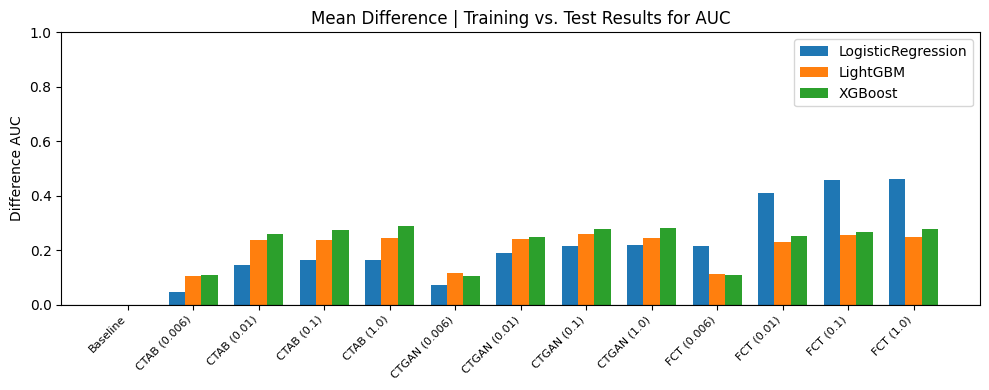

In [25]:
# Load data
train_df = pd.read_excel("Classification_model_performance_per_fold_training.xlsx", sheet_name="Sheet1")
test_df  = pd.read_excel("Classification_model_performance_per_fold.xlsx")

train_df = train_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

test_df = test_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

# Make sure column names are consistent
train_df = train_df.rename(columns={
    "f1": "train_f1",
    "prec": "train_prec",
    "rec": "train_rec",
    "auc": "train_auc",
    "pr_auc": "train_pr_auc"
})

test_df = test_df.rename(columns={
    "f1": "test_f1",
    "prec": "test_prec",
    "rec": "test_rec",
    "auc": "test_auc",
    "pr_auc": "test_pr_auc"
})


# Aggregate per model + data_version (mean over folds)
train_agg = (
    train_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["train_auc"]]
    .mean()
)
test_agg = (
    test_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["test_auc"]]
    .mean()
)

# Merge train + test
df = pd.merge(train_agg, test_agg, on=["model_name", "data_version"], how="inner")

# --- 2. Prepare ordering and compute gap ---
# Nice ordering of GAN versions on x-axis
order = [
    "baseline",
    "ctab", "ctab_0.01", "ctab_0.1", "ctab_1.0",
    "ctgan", "ctgan_0.01", "ctgan_0.1", "ctgan_1.0",
    "fct", "fct_0.01", "fct_0.1", "fct_1.0"
]

df["data_version"] = pd.Categorical(df["data_version"], categories=order, ordered=True)
df = df.sort_values(["data_version", "model_name"])

# Generalization gap = train - test
df["gap_auc"] = df["train_auc"] - df["test_auc"]

# --- 3. Single grouped bar plot: F1 gap by data_version and model ---
models = ["LogisticRegression", "LightGBM", "XGBoost"]
colors = {
    "LogisticRegression": "tab:blue",
    "LightGBM": "tab:orange",
    "XGBoost": "tab:green",
}

x_labels = [v for v in order if v in df["data_version"].unique()]
x = np.arange(len(x_labels))
width = 0.25

plt.figure(figsize=(10, 4))

for i, model in enumerate(models):
    df_m = df[df["model_name"] == model]
    # align with x_labels order
    df_m = df_m.set_index("data_version").reindex(x_labels)
    gaps = df_m["gap_auc"].values

    plt.bar(
        x + (i - 1) * width,
        gaps,
        width,
        label=model,
        color=colors[model]
    )

pretty_labels = {
    "baseline": "Baseline",
    "ctab": "CTAB (0.006)",
    "ctab_0.01": "CTAB (0.01)",
    "ctab_0.1": "CTAB (0.1)",
    "ctab_1.0": "CTAB (1.0)",
    "ctgan": "CTGAN (0.006)",
    "ctgan_0.01": "CTGAN (0.01)",
    "ctgan_0.1": "CTGAN (0.1)",
    "ctgan_1.0": "CTGAN (1.0)",
    "fct": "FCT (0.006)",
    "fct_0.01": "FCT (0.01)",
    "fct_0.1": "FCT (0.1)",
    "fct_1.0": "FCT (1.0)"
}

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, [pretty_labels[v] for v in x_labels], rotation=45, ha="right", fontsize=8)
plt.ylabel("Difference AUC")
plt.ylim((0.0, 1.0))
plt.title("Mean Difference | Training vs. Test Results for AUC")
plt.legend()
plt.tight_layout()
plt.show()


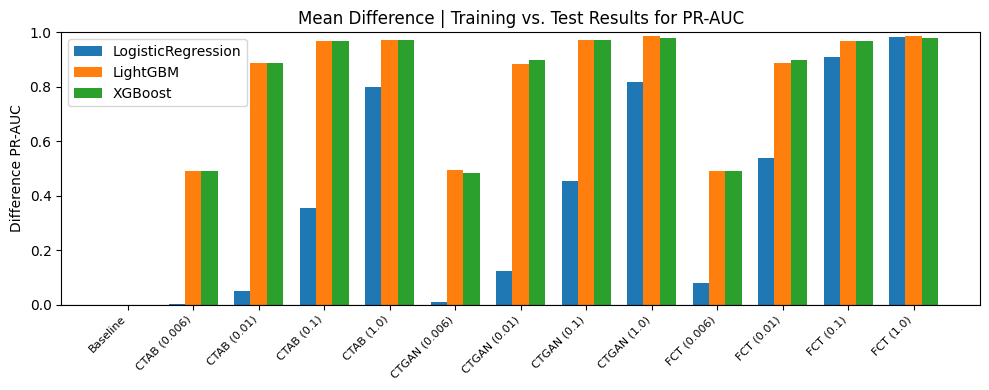

In [26]:
# Load data
train_df = pd.read_excel("Classification_model_performance_per_fold_training.xlsx", sheet_name="Sheet1")
test_df  = pd.read_excel("Classification_model_performance_per_fold.xlsx")

train_df = train_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

test_df = test_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

# Make sure column names are consistent
train_df = train_df.rename(columns={
    "f1": "train_f1",
    "prec": "train_prec",
    "rec": "train_rec",
    "auc": "train_auc",
    "pr_auc": "train_pr_auc"
})

test_df = test_df.rename(columns={
    "f1": "test_f1",
    "prec": "test_prec",
    "rec": "test_rec",
    "auc": "test_auc",
    "pr_auc": "test_pr_auc"
})


# Aggregate per model + data_version (mean over folds)
train_agg = (
    train_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["train_pr_auc"]]
    .mean()
)
test_agg = (
    test_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["test_pr_auc"]]
    .mean()
)

# Merge train + test
df = pd.merge(train_agg, test_agg, on=["model_name", "data_version"], how="inner")

# --- 2. Prepare ordering and compute gap ---
# Nice ordering of GAN versions on x-axis
order = [
    "baseline",
    "ctab", "ctab_0.01", "ctab_0.1", "ctab_1.0",
    "ctgan", "ctgan_0.01", "ctgan_0.1", "ctgan_1.0",
    "fct", "fct_0.01", "fct_0.1", "fct_1.0"
]

df["data_version"] = pd.Categorical(df["data_version"], categories=order, ordered=True)
df = df.sort_values(["data_version", "model_name"])

# Generalization gap = train - test
df["gap_pr_auc"] = df["train_pr_auc"] - df["test_pr_auc"]

# --- 3. Single grouped bar plot: F1 gap by data_version and model ---
models = ["LogisticRegression", "LightGBM", "XGBoost"]
colors = {
    "LogisticRegression": "tab:blue",
    "LightGBM": "tab:orange",
    "XGBoost": "tab:green",
}

x_labels = [v for v in order if v in df["data_version"].unique()]
x = np.arange(len(x_labels))
width = 0.25

plt.figure(figsize=(10, 4))

for i, model in enumerate(models):
    df_m = df[df["model_name"] == model]
    # align with x_labels order
    df_m = df_m.set_index("data_version").reindex(x_labels)
    gaps = df_m["gap_pr_auc"].values

    plt.bar(
        x + (i - 1) * width,
        gaps,
        width,
        label=model,
        color=colors[model]
    )

pretty_labels = {
    "baseline": "Baseline",
    "ctab": "CTAB (0.006)",
    "ctab_0.01": "CTAB (0.01)",
    "ctab_0.1": "CTAB (0.1)",
    "ctab_1.0": "CTAB (1.0)",
    "ctgan": "CTGAN (0.006)",
    "ctgan_0.01": "CTGAN (0.01)",
    "ctgan_0.1": "CTGAN (0.1)",
    "ctgan_1.0": "CTGAN (1.0)",
    "fct": "FCT (0.006)",
    "fct_0.01": "FCT (0.01)",
    "fct_0.1": "FCT (0.1)",
    "fct_1.0": "FCT (1.0)"
}

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, [pretty_labels[v] for v in x_labels], rotation=45, ha="right", fontsize=8)
plt.ylabel("Difference PR-AUC")
plt.ylim((0.0, 1.0))
plt.title("Mean Difference | Training vs. Test Results for PR-AUC")
plt.legend()
plt.tight_layout()
plt.show()


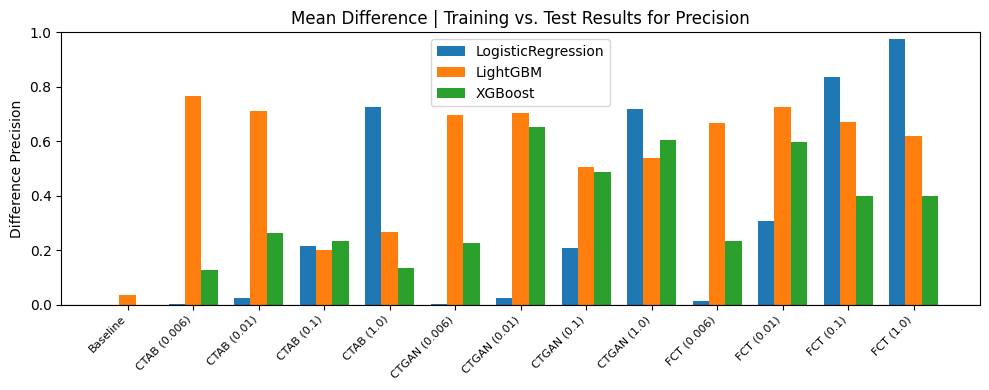

In [27]:
# Load data
train_df = pd.read_excel("Classification_model_performance_per_fold_training.xlsx", sheet_name="Sheet1")
test_df  = pd.read_excel("Classification_model_performance_per_fold.xlsx")

train_df = train_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

test_df = test_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

# Make sure column names are consistent
train_df = train_df.rename(columns={
    "f1": "train_f1",
    "prec": "train_prec",
    "rec": "train_rec",
    "auc": "train_auc",
    "pr_auc": "train_pr_auc"
})

test_df = test_df.rename(columns={
    "f1": "test_f1",
    "prec": "test_prec",
    "rec": "test_rec",
    "auc": "test_auc",
    "pr_auc": "test_pr_auc"
})


# Aggregate per model + data_version (mean over folds)
train_agg = (
    train_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["train_prec"]]
    .mean()
)
test_agg = (
    test_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["test_prec"]]
    .mean()
)

# Merge train + test
df = pd.merge(train_agg, test_agg, on=["model_name", "data_version"], how="inner")

# --- 2. Prepare ordering and compute gap ---
# Nice ordering of GAN versions on x-axis
order = [
    "baseline",
    "ctab", "ctab_0.01", "ctab_0.1", "ctab_1.0",
    "ctgan", "ctgan_0.01", "ctgan_0.1", "ctgan_1.0",
    "fct", "fct_0.01", "fct_0.1", "fct_1.0"
]

df["data_version"] = pd.Categorical(df["data_version"], categories=order, ordered=True)
df = df.sort_values(["data_version", "model_name"])

# Generalization gap = train - test
df["gap_prec"] = df["train_prec"] - df["test_prec"]

# --- 3. Single grouped bar plot: F1 gap by data_version and model ---
models = ["LogisticRegression", "LightGBM", "XGBoost"]
colors = {
    "LogisticRegression": "tab:blue",
    "LightGBM": "tab:orange",
    "XGBoost": "tab:green",
}

x_labels = [v for v in order if v in df["data_version"].unique()]
x = np.arange(len(x_labels))
width = 0.25

plt.figure(figsize=(10, 4))

for i, model in enumerate(models):
    df_m = df[df["model_name"] == model]
    # align with x_labels order
    df_m = df_m.set_index("data_version").reindex(x_labels)
    gaps = df_m["gap_prec"].values

    plt.bar(
        x + (i - 1) * width,
        gaps,
        width,
        label=model,
        color=colors[model]
    )

pretty_labels = {
    "baseline": "Baseline",
    "ctab": "CTAB (0.006)",
    "ctab_0.01": "CTAB (0.01)",
    "ctab_0.1": "CTAB (0.1)",
    "ctab_1.0": "CTAB (1.0)",
    "ctgan": "CTGAN (0.006)",
    "ctgan_0.01": "CTGAN (0.01)",
    "ctgan_0.1": "CTGAN (0.1)",
    "ctgan_1.0": "CTGAN (1.0)",
    "fct": "FCT (0.006)",
    "fct_0.01": "FCT (0.01)",
    "fct_0.1": "FCT (0.1)",
    "fct_1.0": "FCT (1.0)"
}

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, [pretty_labels[v] for v in x_labels], rotation=45, ha="right", fontsize=8)
plt.ylabel("Difference Precision")
plt.ylim((0.0, 1.0))
plt.title("Mean Difference | Training vs. Test Results for Precision")
plt.legend()
plt.tight_layout()
plt.show()


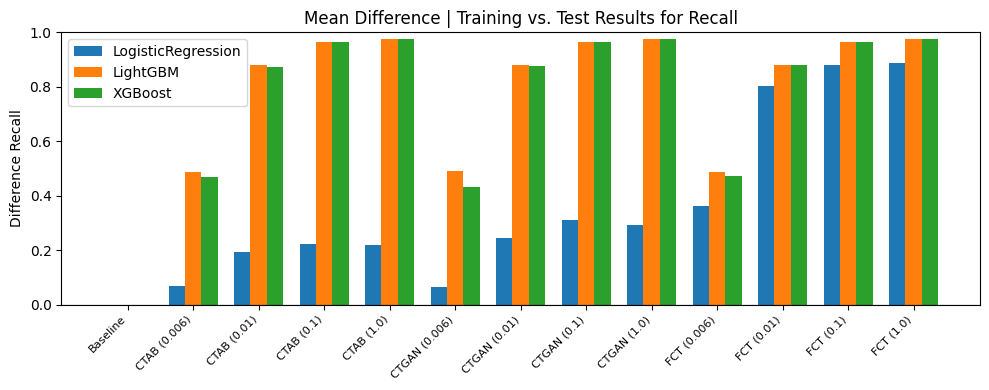

In [28]:
# Load data
train_df = pd.read_excel("Classification_model_performance_per_fold_training.xlsx", sheet_name="Sheet1")
test_df  = pd.read_excel("Classification_model_performance_per_fold.xlsx")

train_df = train_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

test_df = test_df.groupby(["data_version","model_name"]).agg({
    "f1":"mean",
    "prec":"mean",
    "rec":"mean",
    "auc":"mean",
    "pr_auc":"mean"
}).reset_index()

# Make sure column names are consistent
train_df = train_df.rename(columns={
    "f1": "train_f1",
    "prec": "train_prec",
    "rec": "train_rec",
    "auc": "train_auc",
    "pr_auc": "train_pr_auc"
})

test_df = test_df.rename(columns={
    "f1": "test_f1",
    "prec": "test_prec",
    "rec": "test_rec",
    "auc": "test_auc",
    "pr_auc": "test_pr_auc"
})


# Aggregate per model + data_version (mean over folds)
train_agg = (
    train_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["train_rec"]]
    .mean()
)
test_agg = (
    test_df
    .groupby(["model_name", "data_version"], as_index=False)
    [["test_rec"]]
    .mean()
)

# Merge train + test
df = pd.merge(train_agg, test_agg, on=["model_name", "data_version"], how="inner")

# --- 2. Prepare ordering and compute gap ---
# Nice ordering of GAN versions on x-axis
order = [
    "baseline",
    "ctab", "ctab_0.01", "ctab_0.1", "ctab_1.0",
    "ctgan", "ctgan_0.01", "ctgan_0.1", "ctgan_1.0",
    "fct", "fct_0.01", "fct_0.1", "fct_1.0"
]

df["data_version"] = pd.Categorical(df["data_version"], categories=order, ordered=True)
df = df.sort_values(["data_version", "model_name"])

# Generalization gap = train - test
df["gap_rec"] = df["train_rec"] - df["test_rec"]

# --- 3. Single grouped bar plot: F1 gap by data_version and model ---
models = ["LogisticRegression", "LightGBM", "XGBoost"]
colors = {
    "LogisticRegression": "tab:blue",
    "LightGBM": "tab:orange",
    "XGBoost": "tab:green",
}

x_labels = [v for v in order if v in df["data_version"].unique()]
x = np.arange(len(x_labels))
width = 0.25

plt.figure(figsize=(10, 4))

for i, model in enumerate(models):
    df_m = df[df["model_name"] == model]
    # align with x_labels order
    df_m = df_m.set_index("data_version").reindex(x_labels)
    gaps = df_m["gap_rec"].values

    plt.bar(
        x + (i - 1) * width,
        gaps,
        width,
        label=model,
        color=colors[model]
    )

pretty_labels = {
    "baseline": "Baseline",
    "ctab": "CTAB (0.006)",
    "ctab_0.01": "CTAB (0.01)",
    "ctab_0.1": "CTAB (0.1)",
    "ctab_1.0": "CTAB (1.0)",
    "ctgan": "CTGAN (0.006)",
    "ctgan_0.01": "CTGAN (0.01)",
    "ctgan_0.1": "CTGAN (0.1)",
    "ctgan_1.0": "CTGAN (1.0)",
    "fct": "FCT (0.006)",
    "fct_0.01": "FCT (0.01)",
    "fct_0.1": "FCT (0.1)",
    "fct_1.0": "FCT (1.0)"
}

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, [pretty_labels[v] for v in x_labels], rotation=45, ha="right", fontsize=8)
plt.ylabel("Difference Recall")
plt.ylim((0.0, 1.0))
plt.title("Mean Difference | Training vs. Test Results for Recall")
plt.legend()
plt.tight_layout()
plt.show()